In [1]:
import numpy as np
import cv2
from typing import Tuple, Literal, Dict
from scipy.optimize import minimize
from vp_detection import VPDetection
import supervision as sv
import math



## Como obtener la matriz K, R, t sin patron de calibracion ?

![image.png](./vanishing.png)


1. Obtener puntos de fuga en el plano de la imagen correspondientes al plano (X, 0, Z) del mundo real.

>NOTA: Los puntos de fuga se representan como versores (1, 0, 0), (0, 1, 0) y (0, 0, 1) en el mundo real.
Ver: Multiple View Geometry in Computer Vision, Richard Hartley pp. 213-220.

2. Si asumimos cero skew, y que el centro optico es el centro geometrico de la imagen
el unico parametro de K a obtener es la distancia focal, se asume f_x = f_y. 

Ver: Using Vanishing Points for Camera Calibration and Coarse 3D Reconstruction from A Single Image, E. Guillou, D. Meneveaux,
E. Maisel, K. Bouatouch. `pp. 400`

Con esto ya podemos calcular dos columnas de la matriz R,
la tercera columna se obtiene haciendo producto vectorial entre las dos primeras.

3. La incognita que nos queda es el vector posicion de la camara en el espacio (3 variables: CAMx, CAMy, CAMz) . Para ello podemos combinar informacion del entorno
con metodos numericos para hacer una optimizacion multivariable.


Otro enfoque similar cuando los puntos de fuga estan "servidos" se expone en:
`A new camera calibration method from vanishing points in a vision system. B.W. He X.L. Zhou and Y.F. Li.`

In [ ]:
# Funciones de optimizacion

def objective_fun(
    cam_loc: Tuple[float, float, float],
    hoop_2d:Tuple[int, int, int],
    hoop_3d: Tuple[float, float, float],
    k_r: np.array) -> float:
    """
    cam_loc: Tuple[float, float, float] or array like structure.
        this is the variable x to find.
    hoop_2d: Tuple[float, float, float] or array like structure.
        Hoop location in image frame in homogeneous coordinates.
    hoop_3d: Tuple[float, float, float]
        Hoop location in the world (court template).
    k_r: nd.array
        K (camera) matrix multiplied by R (rotation)
    """
    # convert to homo
    hoop_3d_h = np.hstack((hoop_3d, 1))

    I_t = [[1, 0, 0, -cam_loc[0]],
           [0, 1, 0, -cam_loc[1]],
           [0, 0, 1, -cam_loc[2]]]

    hoop_2d_hat_h = k_r @ I_t @ hoop_3d_h
    # to inhomogeneous
    hoop_2d_hat = hoop_2d_hat_h / hoop_2d_hat_h[2]

    err = np.linalg.norm(hoop_2d - hoop_2d_hat)
    return err


def multivar_minimization(
    K: np.ndarray,
    R: np.ndarray,
    hoop_xyz_world: Tuple[float, float, float],
    hoop_xy_img: Tuple[int, int],
    init_camera_loc: Tuple[float, float, float],
    ) -> Tuple[float, float, float]:
    """
    Multivariable minimization to find the camera location in world coordinates
    given the hoop location in image coordinates and world coordinates.

    Parameters
    ----------
    K : np.ndarray
        Camera intrinsic matrix.
    R : np.ndarray
        Camera rotation matrix.
    hoop_xyz_world : Tuple[float, float, float]
        Hoop location in world coordinates (3D).
    hoop_xy_img : Tuple[int, int]
        Hoop location in image coordinates (2D).
    init_camera_loc : Tuple[float, float, float]
        Initial guess for camera location in world coordinates (3D).
    
    Returns
    -------
    Tuple[float, float, float]
        Estimated camera location in world coordinates (3D).
    """
    KR = K @ R

    hoop_xy_img = np.hstack((hoop_xy_img, 1))
    args = hoop_xy_img, hoop_xyz_world, KR

    init_camera_loc = np.array(init_camera_loc)
    bounds = [(None, None), (7, 20), (0, 20)]
    solver = 'Powell'
    res = minimize(
        fun=objective_fun,
        x0=init_camera_loc,
        args=args,
        method=solver,
        bounds=bounds)

    return res.x

In [ ]:
# Funciones para obtener K & R

def get_angles(
    vpoints: Dict[int, Tuple],
    h: int,
    w: int,
    f,
    detected_view: Literal['left', 'right'] = 'left',
):
    """
    Estimates camera's tilt, pan and roll and focal lenght from vanishing
    points. A mapping between world coordinates of vanishing points
    (versors in homogeneous representation) and his 2d location on the
    image frame is performed. Using that mapping  2 columns of the camera
    rotation matrix are computed in a direct way. Since the cols are
    orthonormal the 3th is also computed using cross product between the
    first two.
    """
    high_x = 1 if \
        vpoints[1][0] > vpoints[2][0] else 2
    low_x = 3 - high_x
    if detected_view == "left":
        vz = np.append(vpoints[high_x], 1)
        vx = np.append(vpoints[low_x], 1)
    else:
        vz = np.append(vpoints[low_x], 1)
        vx = np.append(vpoints[high_x], 1)

    K = np.array([[-f, 0, w / 2], [0, f, h / 2], [0, 0, 1]])
    Kinv = np.linalg.inv(K)
    vz = -vz
    vx = -vx if detected_view == "left" else vx
    kinv_vz = Kinv @ vz
    kinv_vx = Kinv @ vx

    r3 = kinv_vz / np.linalg.norm(kinv_vz)
    r1 = kinv_vx / np.linalg.norm(kinv_vx)
    r2 = np.cross(r3.T, r1.T).T

    # check orthogonality
    angle_xz = math.degrees(math.acos(np.dot(r1, r3)))
    if abs(90 - angle_xz) > 0.001:
        print(f"angle_xz should be 90: {angle_xz}")
        return []

    R = np.column_stack((r1, r2, r3))

    #  Rz @ Rx @ Ry
    """
    R = np.array([[cz*cy-sz*sx*sy, -sz*cx, -cz*sy+sz*sx*cy],
                [sz*cy-cz*sx*sy, cz*cx, -sz*sy-cz*sx*cy],
                [cx*sy, sx, cx*cy]])
    """
    tilt_rad = math.asin(r2[2])
    tilt_deg = math.degrees(tilt_rad)
    pan_rad = math.atan(r1[2] / r3[2])
    pan_deg = math.degrees(pan_rad)
    roll_rad = -math.atan(r2[0] / r2[1])
    roll_deg = math.degrees(roll_rad)

    TPR = tilt_deg, pan_deg, roll_deg
    return TPR, R, K

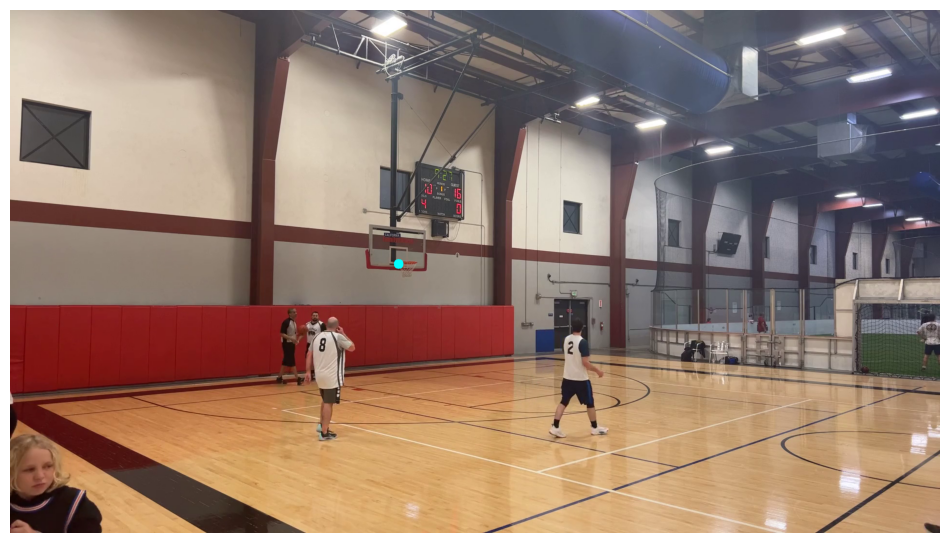

In [4]:
hoop_img_coords = (802, 525)

img = cv2.imread('./court.png')
h, w, _ = img.shape

cv2.circle(
    img, center=hoop_img_coords, radius=10, color=(255, 255, 0), thickness=-1)
sv.plot_image(img)

Puntos de fuga encontrados:
 [[  2349.1        621.4819 ]
 [  -663.0785     596.67914]
 [  1224.5034  -31582.748  ]]


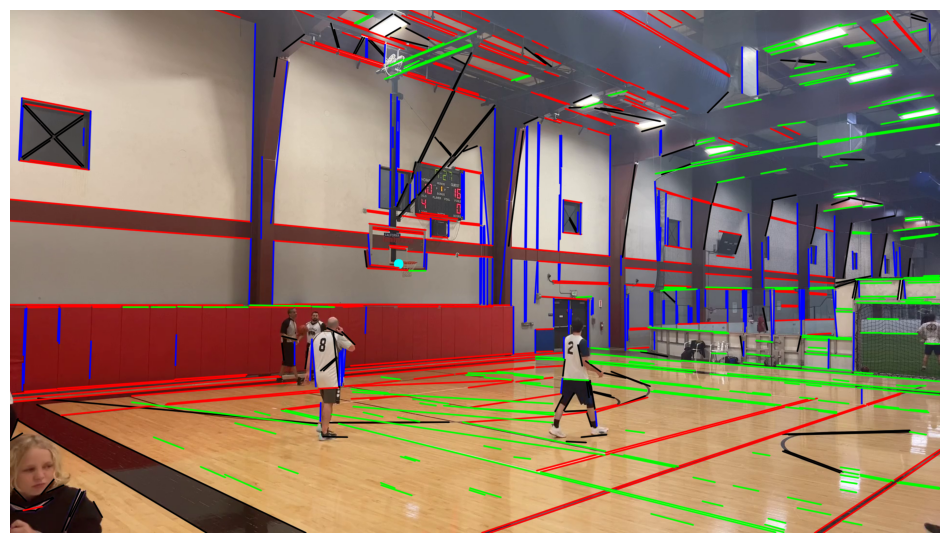

In [5]:
# Para el sistema de coordonadas elegido para el mundo el aro izquierdo esta
# ubicado en x=-43, y=10, z=-25 & (medido en pies)
# nota: El origen del sistema de coordenadas esta en donde la linea que divide
# la cancha en dos mitades se cruza con el lado mas largo cercano a la camara.
# El verson X apunta hacia la derecha, el Y hacia arriba y el Z hacia la camara.

LEFT_HOOP_3D = [-43, 10, -25.0]

# Estimamos en un paso previo la distancia focal
f = 1500

# Detectamos puntos de fuga a partir de lineas rectas en la imagen
vp_detector = VPDetection(length_thresh=30,focal_length=f)
vp_detector.find_vps(img)

vp_x = vp_detector.vps_2D[1]
vp_z = vp_detector.vps_2D[0]

print(f'Puntos de fuga encontrados:\n {vp_detector.vps_2D}')

# Lineas usadas para obtener los puntos de fuga
img_vp = vp_detector.create_debug_VP_image()
sv.plot_image(img_vp)

Puntos de fuga encontrados:
 [[  2621.9414     569.0093 ]
 [  -395.11462    613.125  ]
 [   342.8645  -41665.668  ]]


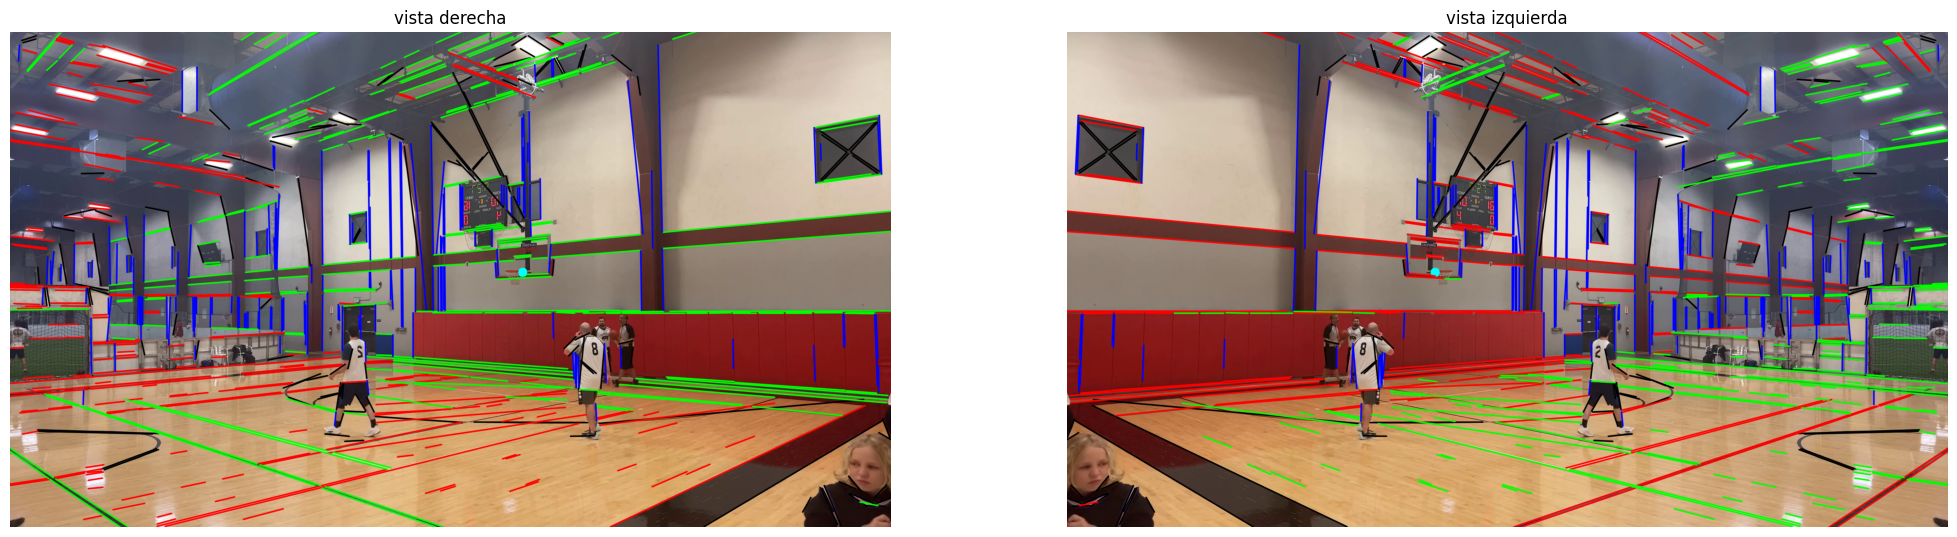

In [6]:
# Notar que los puntos de fuga para versores X y Z se invierten si cambia la vista.
vp_detector_r = VPDetection(length_thresh=30,focal_length=f)

img_right = cv2.flip(img, 1)
vp_detector_r.find_vps(img_right)

print(f'Puntos de fuga encontrados:\n {vp_detector_r.vps_2D}')

# Lineas usadas para obtener los puntos de fuga
img_right_vp = vp_detector_r.create_debug_VP_image()
sv.plot_images_grid(
    images=[img_right_vp, img_vp], 
    grid_size=(1, 2), 
    size=(25, 25),
    titles=['vista derecha', 'vista izquierda'])

In [7]:
vpoints = {1:vp_detector.vps_2D[0], 2:vp_detector.vps_2D[1]}

(tilt, pan, roll), R, K = get_angles(
    vpoints=vpoints, h=h, w=w, f=f, detected_view='left')

print(f'Matriz K:\n{K}')
print(f'Matriz R:\n{R}')
print(f'Tilt: {tilt}, Pan: {pan}, Roll: {roll}')

Matriz K:
[[-1.5e+03  0.0e+00  9.6e+02]
 [ 0.0e+00  1.5e+03  5.4e+02]
 [ 0.0e+00  0.0e+00  1.0e+00]]
Matriz R:
[[-0.73416193  0.00822491  0.67892463]
 [-0.02563749  0.99887774 -0.03982438]
 [-0.67849022 -0.04664347 -0.73312711]]
Tilt: -2.6734439558463925, Pan: 42.783463511804435, Roll: -0.47177145782778024


In [ ]:
# Buscamos la posicion mediante optimizacion numerica

CAM_x, CAM_y, CAM_z = multivar_minimization(
    K=K,
    R=R,
    hoop_xyz_world=LEFT_HOOP_3D,
    hoop_xy_img=hoop_img_coords,
    init_camera_loc=(0, 7, 5)
)
print(f'Posicion de la camara: {CAM_x}, {CAM_y}, {CAM_z}')